In [1]:
# Cell 1
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import pandas as pd

# Ustawienia powtarzalności
#np.random.seed(2025)
%matplotlib inline

In [2]:
class HeiderModelFixed:
    def __init__(self, N=50):
        """
        Inicjalizacja modelu Heidera
        """
        self.N = N
        self.n_edges = N * (N - 1) // 2
        self.n_triangles = N * (N - 1) * (N - 2) // 6
        
        # Macierz relacji
        self.x = self._initialize_random_relations()
        
        # Historia - teraz zawsze w krokach
        self.history = {
            't': [],
            'U': [], 
            'mean_x': []
        }
        
        print(f"Model zainicjalizowany: N={N}, liczba krawędzi={self.n_edges}, liczba trójkątów={self.n_triangles}")
        
    def _initialize_random_relations(self):
        """Inicjalizacja losowych relacji ±1"""
        x = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(i+1, self.N):
                x[i, j] = np.random.choice([-1, 1])
                x[j, i] = x[i, j]
        return x
    
    def calculate_U(self):
        """Obliczenie U - zoptymalizowane"""
        U_sum = 0
        for i in range(self.N):
            for j in range(i+1, self.N):
                for k in range(j+1, self.N):
                    U_sum += self.x[i, j] * self.x[j, k] * self.x[i, k]
        return -U_sum / self.n_triangles
    
    def calculate_mean_x(self):
        """Średnia wartość relacji"""
        upper_triangle = np.triu(self.x, k=1)
        return np.sum(upper_triangle) / self.n_edges
    
    def update_rule(self, i, j):
        """Reguła aktualizacji zgodna z równaniem (32)"""
        mask = np.ones(self.N, dtype=bool)
        mask[i] = mask[j] = False
        sum_products = np.sum(self.x[i, mask] * self.x[j, mask])
        
        if sum_products > 0:
            return 1
        elif sum_products < 0:
            return -1
        else:
            return self.x[i, j]
    
    def synchronous_step(self):
        """
        Jeden krok synchroniczny = aktualizacja wszystkich krawędzi jednocześnie
        """
        new_x = self.x.copy()
        
        for i in range(self.N):
            for j in range(i+1, self.N):
                new_value = self.update_rule(i, j)
                new_x[i, j] = new_value
                new_x[j, i] = new_value
        
        self.x = new_x
    
    def asynchronous_step(self):
        """
        Jeden krok asynchroniczny = aktualizacja wszystkich krawędzi w losowej kolejności
        """
        # Lista wszystkich krawędzi
        edges = [(i, j) for i in range(self.N) for j in range(i+1, self.N)]
        
        # Przemieszaj kolejność
        np.random.shuffle(edges)
        
        # Aktualizuj każdą krawędź po kolei
        for i, j in edges:
            new_value = self.update_rule(i, j)
            self.x[i, j] = new_value
            self.x[j, i] = new_value
    
    def record_state(self, t):
        """Zapisz stan"""
        self.history['t'].append(t)
        self.history['U'].append(self.calculate_U())
        self.history['mean_x'].append(self.calculate_mean_x())
    
    def check_convergence(self, window=10, tolerance=1e-10):
        """Sprawdź konwergencję"""
        if len(self.history['U']) < window:
            return False
        
        recent_U = self.history['U'][-window:]
        return np.std(recent_U) < tolerance
    
    def is_paradise(self):
        """Czy wszystkie relacje są pozytywne"""
        return np.allclose(self.calculate_mean_x(), 1.0, atol=1e-6)
    
    def is_balanced(self):
        """Czy układ jest zbalansowany"""
        return np.isclose(self.calculate_U(), -1.0, atol=1e-6)
    
    def run_simulation(self, max_steps=1000, mode='synchronous', 
                      check_conv_every=10, verbose=True):
        """
        Symulacja - teraz oba tryby liczą kroki w ten sam sposób
        """
        if verbose:
            print(f"\nRozpoczynam symulację {mode}")
            print(f"Stan początkowy: U={self.calculate_U():.4f}, <x>={self.calculate_mean_x():.4f}")
        
        # Zapisz stan początkowy
        self.record_state(0)
        
        for t in range(1, max_steps + 1):
            # Wykonaj jeden krok (synchroniczny lub asynchroniczny)
            if mode == 'synchronous':
                self.synchronous_step()
            else:
                self.asynchronous_step()
            
            # Zapisz stan
            self.record_state(t)
            
            # Sprawdź konwergencję
            if t % check_conv_every == 0:
                if self.check_convergence():
                    if verbose:
                        print(f"Konwergencja po {t} krokach")
                    break
                    
                if verbose and t % 100 == 0:
                    U = self.history['U'][-1]
                    mean_x = self.history['mean_x'][-1]
                    print(f"  Krok {t}: U={U:.4f}, <x>={mean_x:.4f}")
        
        # Określ typ stanu końcowego
        final_U = self.calculate_U()
        final_mean_x = self.calculate_mean_x()
        
        state_type = "INNY"
        if self.is_paradise():
            state_type = "RAJ"
        elif self.is_balanced():
            state_type = "ZBALANSOWANY (nie-raj)"
        
        if verbose:
            print(f"\nStan końcowy: {state_type}")
            print(f"U={final_U:.6f}, <x>={final_mean_x:.6f}")
            print(f"Liczba kroków: {len(self.history['t'])-1}")
        
        return state_type
    
    def plot_evolution(self, title=""):
        """Wizualizacja ewolucji"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # Wykres U
        ax1.plot(self.history['t'], self.history['U'], 'b-', linewidth=2, 
                marker='o', markersize=3, markevery=max(1, len(self.history['t'])//50))
        ax1.axhline(y=-1, color='r', linestyle='--', alpha=0.7, label='U = -1')
        ax1.set_ylabel('U', fontsize=12)
        ax1.set_title('Ewolucja miary zbalansowania U', fontsize=14)
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Wykres <x>
        ax2.plot(self.history['t'], self.history['mean_x'], 'g-', linewidth=2,
                marker='s', markersize=3, markevery=max(1, len(self.history['t'])//50))
        ax2.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='<x> = 1 (raj)')
        ax2.axhline(y=-1, color='b', linestyle='--', alpha=0.7, label='<x> = -1')
        ax2.axhline(y=0, color='k', linestyle=':', alpha=0.5)
        ax2.set_xlabel('Krok', fontsize=12)
        ax2.set_ylabel('<x>', fontsize=12)
        ax2.set_title('Ewolucja średniej relacji', fontsize=14)
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        if title:
            fig.suptitle(title, fontsize=16)
        
        plt.tight_layout()
        return fig
    
    def save_state(self, filename):
        """Zapisz stan końcowy"""
        with open(filename, 'w') as f:
            f.write("i,j,x_ij\n")
            for i in range(self.N):
                for j in range(i+1, self.N):
                    f.write(f"{i},{j},{self.x[i,j]}\n")

In [3]:
# Cell 2: Porównanie synchronicznej i asynchronicznej z tym samym stanem początkowym
def compare_methods_same_initial(N=50, max_steps=200):
    """
    Porównaj obie metody startując z tego samego stanu początkowego
    """
    print("=== PORÓWNANIE METOD (TEN SAM STAN POCZĄTKOWY) ===\n")
    
    # Utwórz pierwszy model
    model_sync = HeiderModelFixed(N=N)
    initial_state = model_sync.x.copy()
    
    # Drugi model z tym samym stanem początkowym
    model_async = HeiderModelFixed(N=N)
    model_async.x = initial_state.copy()
    
    # Symulacje
    print("1. Aktualizacja SYNCHRONICZNA")
    state_sync = model_sync.run_simulation(max_steps=max_steps, mode='synchronous')
    
    print("\n2. Aktualizacja ASYNCHRONICZNA")  
    state_async = model_async.run_simulation(max_steps=max_steps, mode='asynchronous')
    
    # Porównanie wykresów
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Synchroniczna
    ax1.plot(model_sync.history['t'], model_sync.history['U'], 'b-', linewidth=2, label='Synchroniczna')
    ax1.axhline(y=-1, color='r', linestyle='--', alpha=0.7)
    ax1.set_title('Synchroniczna: U(t)', fontsize=14)
    ax1.set_xlabel('Krok')
    ax1.set_ylabel('U')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    ax2.plot(model_sync.history['t'], model_sync.history['mean_x'], 'g-', linewidth=2, label='Synchroniczna')
    ax2.axhline(y=1, color='r', linestyle='--', alpha=0.7)
    ax2.axhline(y=-1, color='b', linestyle='--', alpha=0.7)
    ax2.set_title('Synchroniczna: <x>(t)', fontsize=14)
    ax2.set_xlabel('Krok')
    ax2.set_ylabel('<x>')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Asynchroniczna
    ax3.plot(model_async.history['t'], model_async.history['U'], 'b--', linewidth=2, label='Asynchroniczna')
    ax3.axhline(y=-1, color='r', linestyle='--', alpha=0.7)
    ax3.set_title('Asynchroniczna: U(t)', fontsize=14)
    ax3.set_xlabel('Krok')
    ax3.set_ylabel('U')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    ax4.plot(model_async.history['t'], model_async.history['mean_x'], 'g--', linewidth=2, label='Asynchroniczna')
    ax4.axhline(y=1, color='r', linestyle='--', alpha=0.7)
    ax4.axhline(y=-1, color='b', linestyle='--', alpha=0.7)
    ax4.set_title('Asynchroniczna: <x>(t)', fontsize=14)
    ax4.set_xlabel('Krok')
    ax4.set_ylabel('<x>')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.suptitle(f'Porównanie metod aktualizacji (N={N})', fontsize=16)
    plt.tight_layout()
    
    # Porównanie bezpośrednie
    fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(15, 6))
    
    # U - obie metody
    ax5.plot(model_sync.history['t'], model_sync.history['U'], 'b-', linewidth=2, label='Synchroniczna')
    ax5.plot(model_async.history['t'], model_async.history['U'], 'r--', linewidth=2, label='Asynchroniczna')
    ax5.axhline(y=-1, color='k', linestyle=':', alpha=0.7)
    ax5.set_title('Porównanie ewolucji U', fontsize=14)
    ax5.set_xlabel('Krok')
    ax5.set_ylabel('U')
    ax5.grid(True, alpha=0.3)
    ax5.legend()
    
    # <x> - obie metody
    ax6.plot(model_sync.history['t'], model_sync.history['mean_x'], 'b-', linewidth=2, label='Synchroniczna')
    ax6.plot(model_async.history['t'], model_async.history['mean_x'], 'r--', linewidth=2, label='Asynchroniczna')
    ax6.axhline(y=1, color='k', linestyle=':', alpha=0.7, label='<x> = 1 (raj)')
    ax6.axhline(y=-1, color='k', linestyle=':', alpha=0.7, label='<x> = -1')
    ax6.set_title('Porównanie ewolucji <x>', fontsize=14)
    ax6.set_xlabel('Krok')
    ax6.set_ylabel('<x>')
    ax6.grid(True, alpha=0.3)
    ax6.legend()
    
    plt.suptitle(f'Bezpośrednie porównanie metod (N={N})', fontsize=16)
    plt.tight_layout()
    
    # Podsumowanie
    print("\n=== PODSUMOWANIE PORÓWNANIA ===")
    print(f"Synchroniczna: {len(model_sync.history['t'])-1} kroków do konwergencji")
    print(f"Asynchroniczna: {len(model_async.history['t'])-1} kroków do konwergencji")
    print(f"\nRóżnica: {abs(len(model_sync.history['t']) - len(model_async.history['t']))} kroków")
    
    return model_sync, model_async


In [4]:
# Cell 4: Szukanie stanów raju
def find_paradise_states(N=50, max_attempts=1000):
    """
    Dedykowana funkcja do szukania stanów raju
    """
    print("=== SZUKANIE STANÓW RAJU ===\n")
    
    paradise_found = {'synchronous': None, 'asynchronous': None}
    balanced_found = {'synchronous': None, 'asynchronous': None}
    
    for attempt in range(1, max_attempts + 1):
        if all(paradise_found.values()) and all(balanced_found.values()):
            break
        
        if attempt % 100 == 0:
            print(f"Próba {attempt}...")
        
        for mode in ['synchronous', 'asynchronous']:
            if paradise_found[mode] and balanced_found[mode]:
                continue
            
            model = HeiderModelFixed(N=N)
            
            # Dłuższe symulacje dla większej szansy na raj
            max_steps = 2000 if mode == 'synchronous' else 1000
            
            state = model.run_simulation(max_steps=max_steps, mode=mode, verbose=False)
            
            if state == "RAJ" and not paradise_found[mode]:
                print(f"\n✓ ZNALEZIONO STAN RAJU ({mode}, próba {attempt})")
                paradise_found[mode] = model
                model.save_state(f'stan_raj_{mode}.csv')
                
            elif state == "ZBALANSOWANY (nie-raj)" and not balanced_found[mode]:
                print(f"\n✓ ZNALEZIONO STAN ZBALANSOWANY ({mode}, próba {attempt})")
                balanced_found[mode] = model
                model.save_state(f'stan_zbalansowany_{mode}.csv')
    
    # Wizualizacja znalezionych stanów
    for state_name, models in [('RAJ', paradise_found), ('ZBALANSOWANY', balanced_found)]:
        for mode, model in models.items():
            if model:
                fig = model.plot_evolution(f"{state_name} - {mode}")
                plt.savefig(f'ewolucja_{state_name.lower()}_{mode}.png')
                plt.show()
    
    return paradise_found, balanced_found


KROK 1: Porównanie metod

=== PORÓWNANIE METOD (TEN SAM STAN POCZĄTKOWY) ===

Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
1. Aktualizacja SYNCHRONICZNA

Rozpoczynam symulację synchronous
Stan początkowy: U=0.0120, <x>=-0.0073
Konwergencja po 20 krokach

Stan końcowy: ZBALANSOWANY (nie-raj)
U=-1.000000, <x>=0.005714
Liczba kroków: 20

2. Aktualizacja ASYNCHRONICZNA

Rozpoczynam symulację asynchronous
Stan początkowy: U=0.0120, <x>=-0.0073
Konwergencja po 20 krokach

Stan końcowy: ZBALANSOWANY (nie-raj)
U=-1.000000, <x>=-0.005714
Liczba kroków: 20

=== PODSUMOWANIE PORÓWNANIA ===
Synchroniczna: 20 kroków do konwergencji
Asynchroniczna: 20 kroków do konwergencji

Różnica: 0 kroków


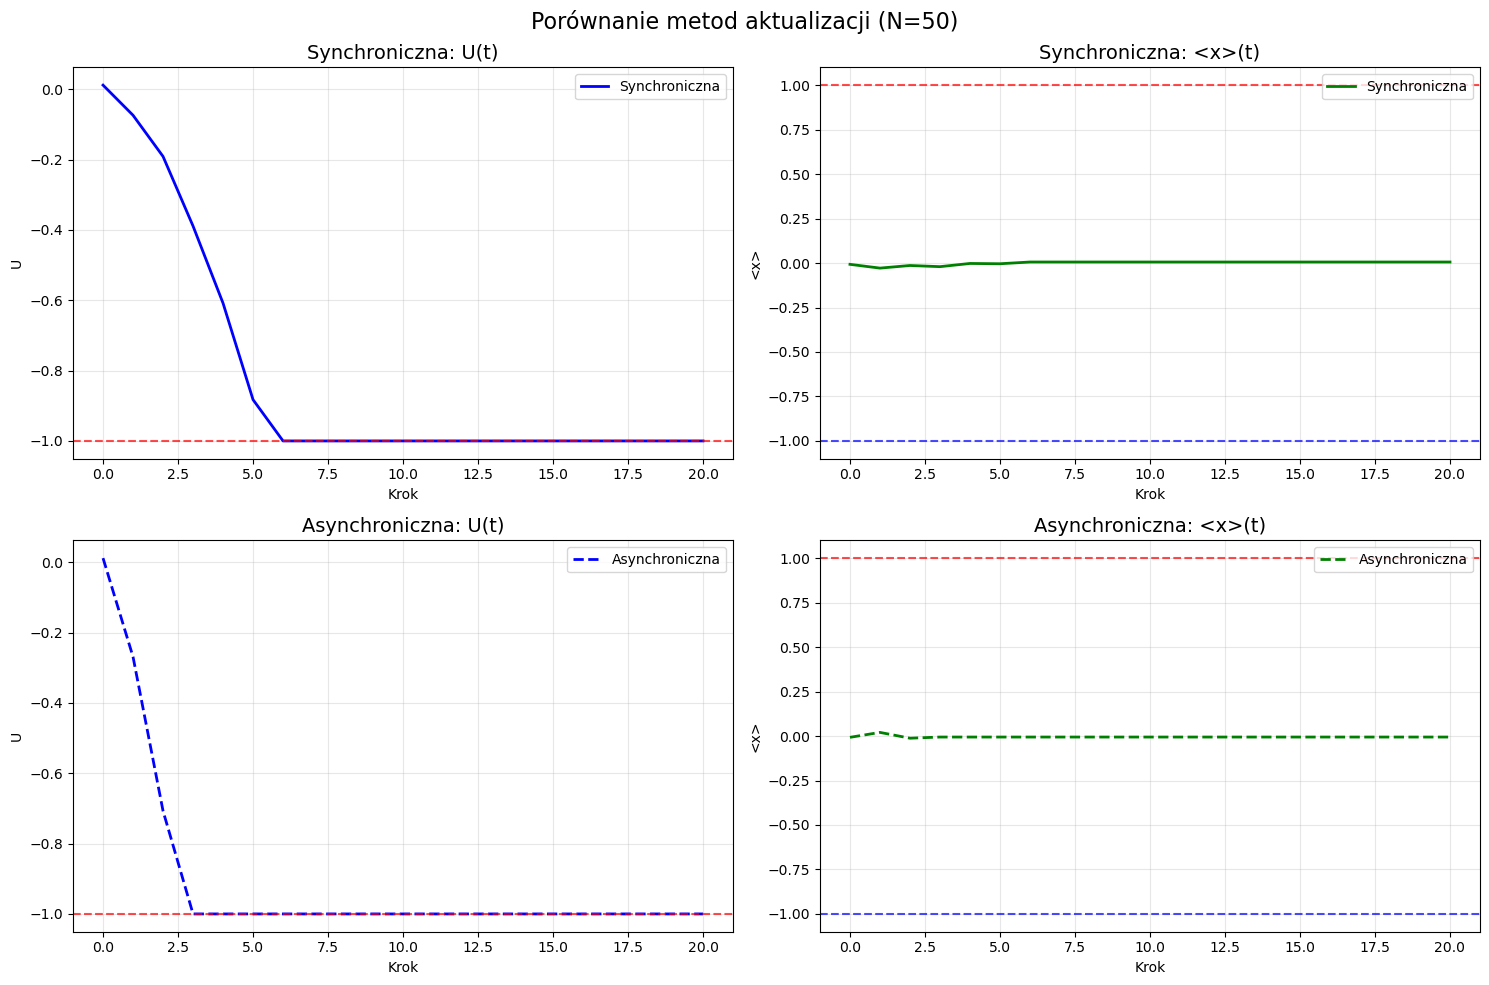

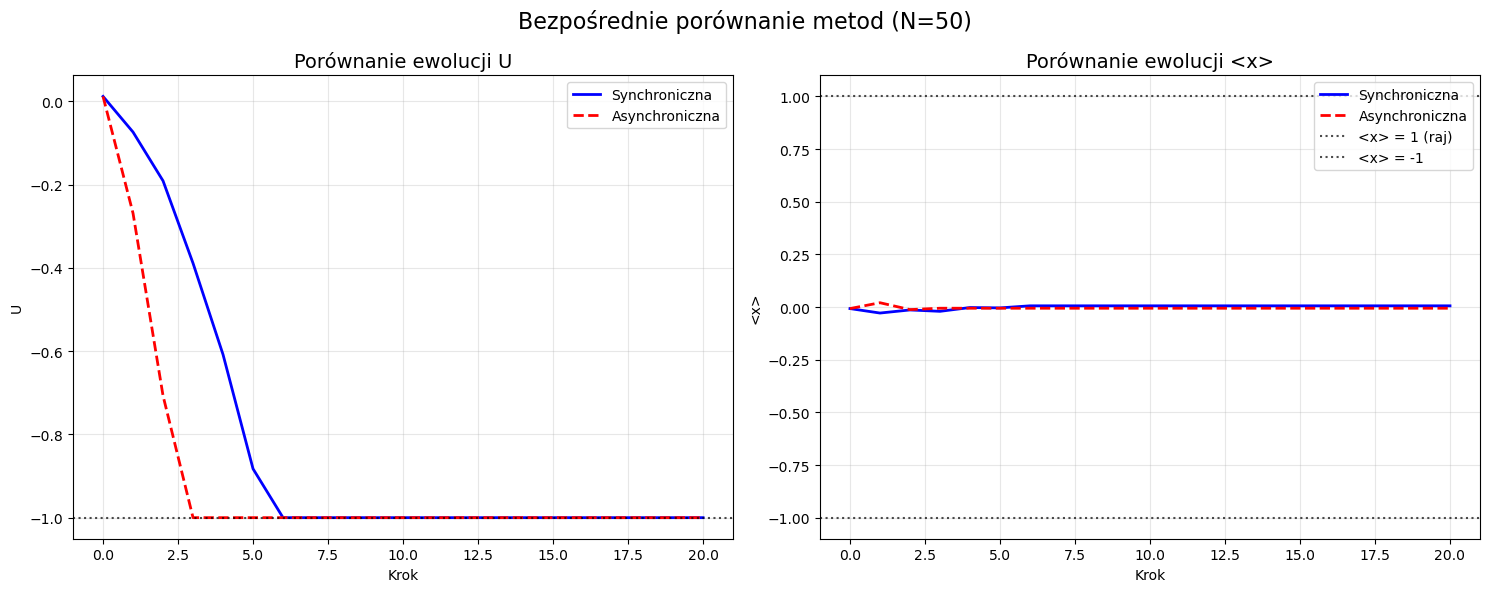



KROK 3: Szukanie stanów raju i zbalansowanych

=== SZUKANIE STANÓW RAJU ===

Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600

✓ ZNALEZIONO STAN ZBALANSOWANY (synchronous, próba 1)
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600

✓ ZNALEZIONO STAN ZBALANSOWANY (asynchronous, próba 1)
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600
Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba t

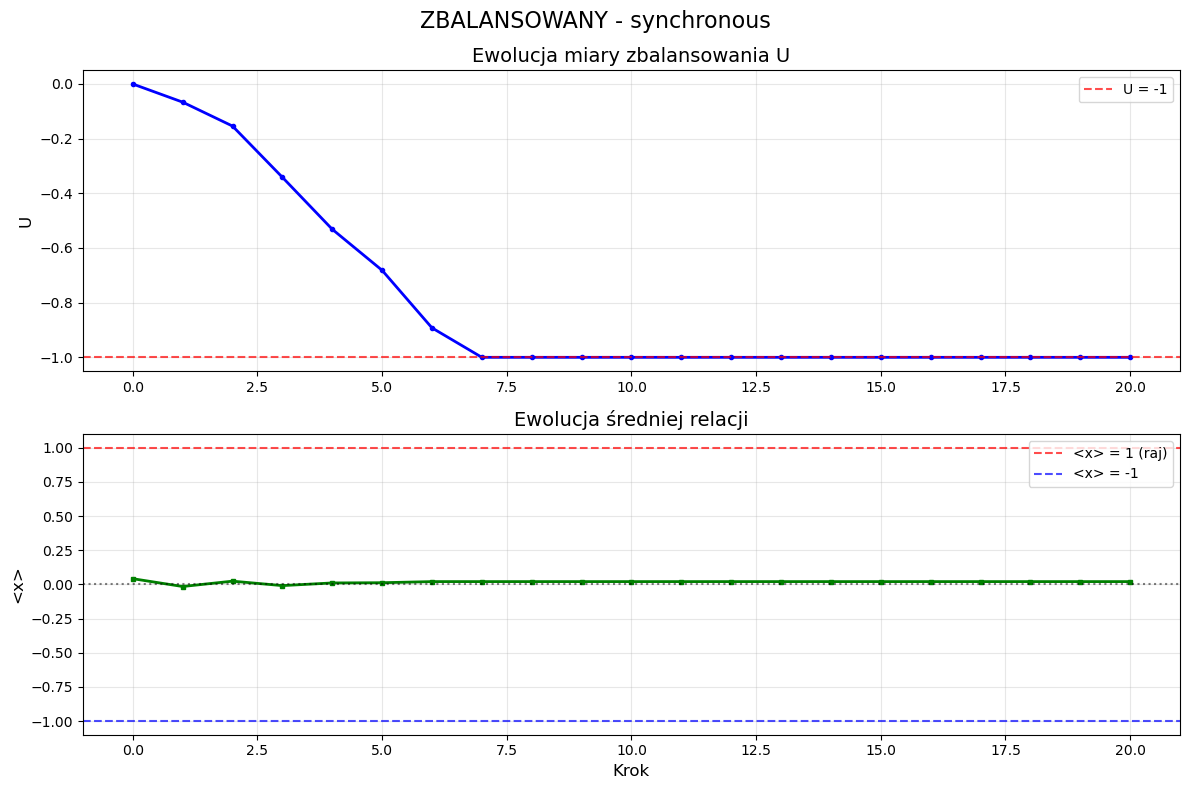

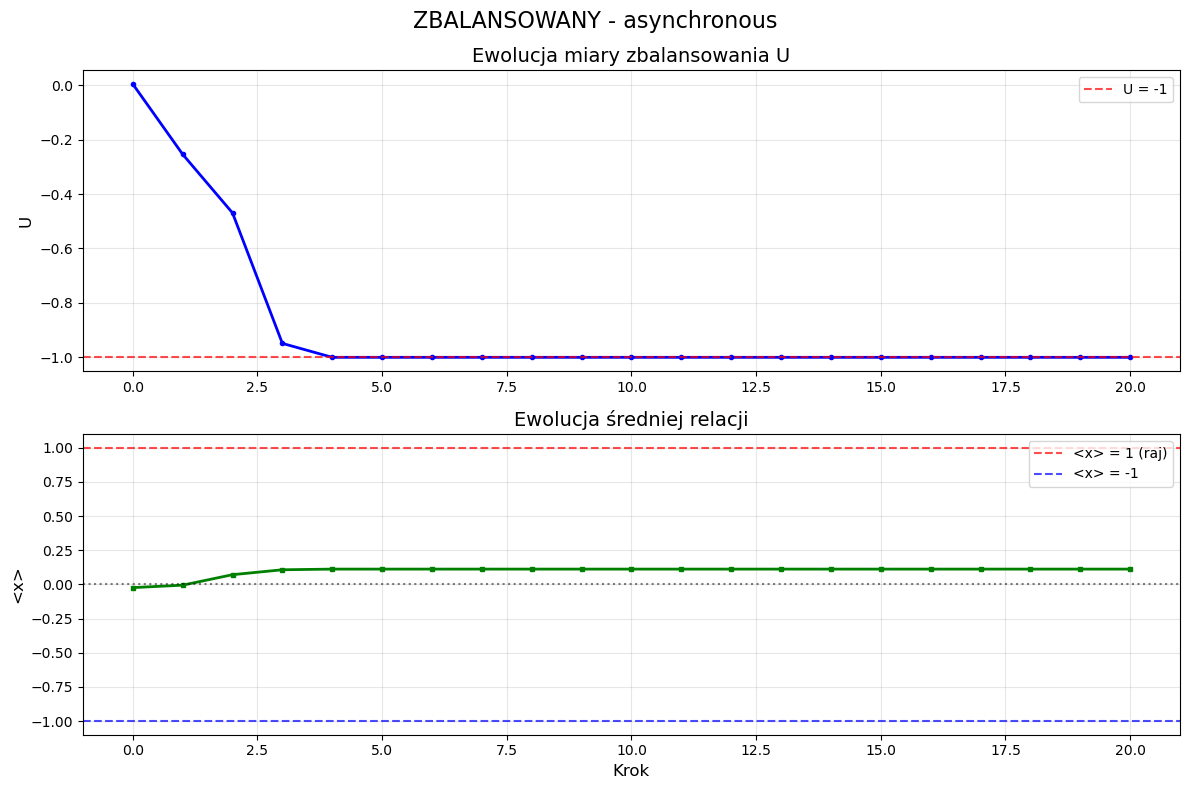



KROK 4: Wizualizacja małej sieci (N=10)

Model zainicjalizowany: N=50, liczba krawędzi=1225, liczba trójkątów=19600

Rozpoczynam symulację synchronous
Stan początkowy: U=0.0059, <x>=0.0057
Konwergencja po 20 krokach

Stan końcowy: ZBALANSOWANY (nie-raj)
U=-1.000000, <x>=-0.005714
Liczba kroków: 20


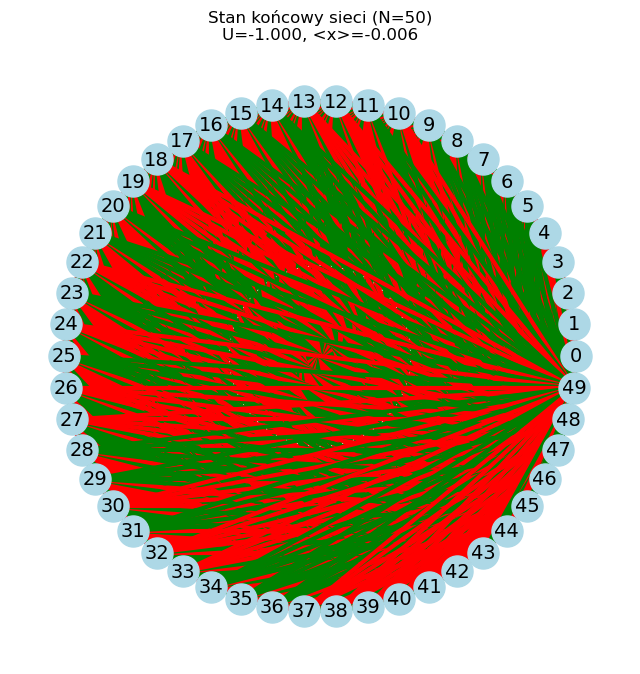

In [ ]:
# Cell 5: Główny eksperyment
if __name__ == "__main__":
    # 1. Porównanie metod z tym samym stanem początkowym
    print("KROK 1: Porównanie metod\n")
    model_sync, model_async = compare_methods_same_initial(N=50, max_steps=200)
    plt.show()
    
    # 3. Szukanie różnych stanów
    print("\n\nKROK 3: Szukanie stanów raju i zbalansowanych\n")
    paradise_states, balanced_states = find_paradise_states(N=50, max_attempts=500)
    
    # 4. Przykład dla małej sieci z wizualizacją
    print("\n\nKROK 4: Wizualizacja małej sieci (N=50)\n")
    model_small = HeiderModelFixed(N=50)
    model_small.run_simulation(max_steps=50, mode='synchronous')
    
    # Wizualizuj sieć
    G = nx.Graph()
    for i in range(model_small.N):
        for j in range(i+1, model_small.N):
            if model_small.x[i, j] > 0:
                G.add_edge(i, j, color='green', weight=1)
            else:
                G.add_edge(i, j, color='red', weight=-1)
    
    plt.figure(figsize=(8, 8))
    pos = nx.circular_layout(G)
    edges = G.edges()
    colors = [G[u][v]['color'] for u, v in edges]
    
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
    nx.draw_networkx_labels(G, pos, font_size=14)
    nx.draw_networkx_edges(G, pos, edge_color=colors, width=3)
    
    plt.title(f'Stan końcowy sieci (N=50)\nU={model_small.calculate_U():.3f}, <x>={model_small.calculate_mean_x():.3f}')
    plt.axis('off')
    plt.show()